<a href="https://colab.research.google.com/github/Lobnaait/SEARCH_Lobna_Tsetline_CMRI/blob/main/DNN_ACDCdatset2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [170]:
from huggingface_hub import snapshot_download
data_dir = snapshot_download(repo_id="mathpluscode/ACDC", allow_patterns=["*.nii.gz", "*.csv"], repo_type="dataset")
!ls /root/.cache/huggingface/hub/datasets--mathpluscode--ACDC/snapshots/4a312b610f395eda5dc0aa36f087dd6ca9991e41/
!pip install -q torch

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 752 files:   0%|          | 0/752 [00:00<?, ?it/s]

test  test.csv	train  train.csv


In [171]:
#IMPORT LIBRARIES
import os
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, auc, roc_auc_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [172]:
#EXTRACT DATASET
import os

train = pd.read_csv(os.path.join(data_dir, "train.csv"))
test = pd.read_csv(os.path.join(data_dir, "test.csv"))

print(train.shape)
print(test.shape)

train.head(10)

(100, 15)
(50, 15)


,pid,pathology,height,weight,bmi,n_frames,ed_frame,es_frame,original_sax_spacing_x,original_sax_spacing_y,original_sax_spacing_z,n_slices,edv,esv,ef
0,patient001,DCM,1.84,95.0,28.060019,30,1,12,1.562500,1.562500,10.0,10,1354.58,1125.97,16.876818
1,patient002,DCM,1.60,70.0,27.343750,30,1,12,1.367188,1.367188,10.0,10,1212.69,979.53,19.226678
2,patient003,DCM,1.65,77.0,28.282828,30,1,15,1.562500,1.562500,10.0,10,1405.42,1298.96,7.574960
3,patient004,DCM,1.59,46.0,18.195483,28,1,15,1.367188,1.367188,10.0,10,1226.58,1114.83,9.110698
4,patient005,DCM,1.65,77.0,28.282828,30,1,13,1.406250,1.406250,10.0,10,1446.55,1211.36,16.258684
5,patient006,DCM,1.80,70.0,21.604938,28,1,16,1.757812,1.757812,10.0,11,1637.74,1374.18,16.092909
6,patient007,DCM,1.73,107.0,35.751278,16,1,7,1.875000,1.875000,10.0,10,1589.67,1411.75,11.192260
7,patient008,DCM,1.80,100.0,30.864198,28,1,13,1.562500,1.562500,10.0,10,1332.23,1158.90,13.010516
8,patient009,DCM,1.53,61.0,26.058354,35,1,13,1.367190,1.367190,10.0,10,1254.25,1154.37,7.963325
9,patient010,DCM,1.70,68.0,23.529412,28,1,13,1.562500,1.562500,10.0,10,1484.35,1316.59,11.301917


In [173]:
TARGET = "pathology"
print(train[TARGET].value_counts())

pathology
DCM     20
HCM     20
MINF    20
NOR     20
RV      20
Name: count, dtype: int64


In [174]:
# EXTRACT TRAINING SET AND VALIDATION SET
print(train.columns.tolist())
features = train.columns.tolist()
features.remove(TARGET)
features.remove('pid')
print(features)

print("\n ")
X = train[features].copy()
y = train[TARGET].copy()

print("X_train shape:", X.shape)
print("y_train shape:", y.shape)
print("\nClasses:", y.value_counts())


['pid', 'pathology', 'height', 'weight', 'bmi', 'n_frames', 'ed_frame', 'es_frame', 'original_sax_spacing_x', 'original_sax_spacing_y', 'original_sax_spacing_z', 'n_slices', 'edv', 'esv', 'ef']
['height', 'weight', 'bmi', 'n_frames', 'ed_frame', 'es_frame', 'original_sax_spacing_x', 'original_sax_spacing_y', 'original_sax_spacing_z', 'n_slices', 'edv', 'esv', 'ef']

 
X_train shape: (100, 13)
y_train shape: (100,)

Classes: pathology
DCM     20
HCM     20
MINF    20
NOR     20
RV      20
Name: count, dtype: int64


In [175]:
# EXTRACT TEST SET
features = test.columns.tolist()
features.remove(TARGET)
features.remove('pid')

X_test = test[features].copy()
y_test = test[TARGET].copy()

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("\nClasses:", y_test.value_counts())

X_test shape: (50, 13)
y_test shape: (50,)

Classes: pathology
DCM     10
NOR     10
MINF    10
HCM     10
RV      10
Name: count, dtype: int64


In [176]:
# ---------------------------------------------------------
# DNN classifier
# A small feed-forward network with configurable hidden width.
# ---------------------------------------------------------
class ACDCClassifier(nn.Module):
    def __init__(self, n_features, n_classes, hidden_dim=64, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, n_classes),
        )

    def forward(self, x):
        return self.net(x)


In [177]:
# ---------------------------------------------------------
# Train/evaluate helper
# Tracks train AND validation loss/macro-F1 every epoch so we can
# diagnose over/underfitting later (gap between train and val curves).
# ---------------------------------------------------------
def train_dnn(X_train, y_train, X_val, y_val, n_classes,
              hidden_dim=64, epochs=1000, lr=1e-3, batch_size=32, dropout=0.3):

    train_ds = TensorDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).long())
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    X_train_t = torch.from_numpy(X_train).float().to(device)
    X_val_t = torch.from_numpy(X_val).float().to(device)

    model = ACDCClassifier(X_train.shape[1], n_classes, hidden_dim=hidden_dim, dropout=dropout).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}
    best_macro_f1, best_state, best_epoch = -1.0, None, 0

    for epoch in range(epochs):
        model.train()
        running_loss, n_batches = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            opt.step()
            running_loss += loss.item()
            n_batches += 1

        # --- evaluate on train and val at the end of the epoch ---
        model.eval()
        with torch.no_grad():
            train_logits = model(X_train_t)
            train_loss_epoch = criterion(train_logits, torch.from_numpy(y_train).long().to(device)).item()
            train_preds = train_logits.argmax(1).cpu().numpy()

            val_logits = model(X_val_t)
            val_loss_epoch = criterion(val_logits, torch.from_numpy(y_val).long().to(device)).item()
            val_preds = val_logits.argmax(1).cpu().numpy()

        train_f1 = f1_score(y_train, train_preds, average="macro")
        macro_f1 = f1_score(y_val, val_preds, average="macro")

        history["train_loss"].append(train_loss_epoch)
        history["val_loss"].append(val_loss_epoch)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(macro_f1)

        if macro_f1 > best_macro_f1:
            best_macro_f1 = macro_f1
            best_epoch = epoch
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

    history["best_epoch"] = best_epoch

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_t).argmax(1).cpu().numpy()
    return model, val_preds, history


In [178]:
# Reproducible split
X_train, X_validation, y_train, y_validation = train_test_split(X, y, test_size=0.25, stratify=y, random_state=SEED)

# Convert pandas dataframes to NumPy
X_train_np = X_train.to_numpy(dtype=np.float32)
X_validation_np = X_validation.to_numpy(dtype=np.float32)
X_test_np = X_test.to_numpy(dtype=np.float32)

# Encode class labels as integers
label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train)
y_validation_enc = label_encoder.transform(y_validation)
y_test_enc = label_encoder.transform(y_test)

N_CLASSES = len(label_encoder.classes_)


In [179]:
# ---------------------------------------------------------
# Find the optimal model capacity (hidden layer width)
#
# Why K-fold CV instead of the single train/validation split:
# with only ~100 training samples, a single split is noisy, so picking
# the hidden_dim that happens to win on one split risks overfitting the
# *validation set itself*. Cross-validation averages over several
# splits, giving a more reliable estimate of how each capacity
# generalizes.
#
# For every candidate width we record BOTH the training and the
# validation macro-F1 (averaged across folds). Comparing them tells us
# where the model sits on the bias/variance spectrum:
#   - low train F1 AND low val F1            -> underfitting (too small)
#   - high train F1 but much lower val F1     -> overfitting (too large)
#   - train F1 approx val F1, both reasonably high -> good capacity
# ---------------------------------------------------------

from sklearn.model_selection import StratifiedKFold

hidden_dim_candidates = [4, 8, 16, 32, 64, 128, 256]
N_SPLITS = 5

cv_results = []

for hidden_dim in hidden_dim_candidates:
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    fold_train_f1, fold_val_f1 = [], []

    for tr_idx, va_idx in skf.split(X_train_np, y_train_enc):
        X_tr, X_va = X_train_np[tr_idx], X_train_np[va_idx]
        y_tr, y_va = y_train_enc[tr_idx], y_train_enc[va_idx]

        # scaler fit ONLY on this fold's training data (no leakage)
        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_tr)
        X_va_scaled = scaler.transform(X_va)

        _, _, history = train_dnn(
            X_tr_scaled, y_tr, X_va_scaled, y_va,
            n_classes=N_CLASSES, hidden_dim=hidden_dim, epochs=1000,
        )

        best_epoch = history["best_epoch"]
        fold_train_f1.append(history["train_f1"][best_epoch])
        fold_val_f1.append(history["val_f1"][best_epoch])

    mean_train_f1 = float(np.mean(fold_train_f1))
    mean_val_f1 = float(np.mean(fold_val_f1))
    std_val_f1 = float(np.std(fold_val_f1))
    gap = mean_train_f1 - mean_val_f1

    cv_results.append({
        "hidden_dim": hidden_dim,
        "mean_train_f1": mean_train_f1,
        "mean_val_f1": mean_val_f1,
        "std_val_f1": std_val_f1,
        "gap": gap,
    })

    print(f"Hidden dim: {hidden_dim:3d} | train F1: {mean_train_f1:.3f} | "
          f"val F1: {mean_val_f1:.3f} (+/-{std_val_f1:.3f}) | gap (overfit signal): {gap:.3f}")


Hidden dim:   4 | train F1: 0.708 | val F1: 0.598 (+/-0.123) | gap (overfit signal): 0.110
Hidden dim:   8 | train F1: 0.836 | val F1: 0.711 (+/-0.036) | gap (overfit signal): 0.125
Hidden dim:  16 | train F1: 0.815 | val F1: 0.710 (+/-0.078) | gap (overfit signal): 0.104
Hidden dim:  32 | train F1: 0.829 | val F1: 0.677 (+/-0.068) | gap (overfit signal): 0.152
Hidden dim:  64 | train F1: 0.728 | val F1: 0.670 (+/-0.101) | gap (overfit signal): 0.058
Hidden dim: 128 | train F1: 0.906 | val F1: 0.646 (+/-0.118) | gap (overfit signal): 0.260
Hidden dim: 256 | train F1: 0.942 | val F1: 0.637 (+/-0.119) | gap (overfit signal): 0.305


In [180]:
cv_df = pd.DataFrame(cv_results).sort_values("hidden_dim").reset_index(drop=True)
print(cv_df)

# ---------------------------------------------------------
# Model-selection rule: "1-standard-error" rule (common for
# bias/variance trade-offs, e.g. used to pick lambda in LASSO/Ridge).
#
# Instead of blindly taking the hidden_dim with the single highest
# validation F1 (which could just be noise, and tends to pick an
# unnecessarily large/overfit-prone network), we:
#   1. find the best mean validation F1 across candidates
#   2. compute a tolerance band = best_score - std_of_best
#   3. among all candidates that fall within that band, pick the
#      SMALLEST hidden_dim (simplest model that is statistically as
#      good as the best one) -> this is the sweet spot that avoids
#      both underfitting and unnecessary overfitting.
# ---------------------------------------------------------
best_row = cv_df.loc[cv_df["mean_val_f1"].idxmax()]
best_score, best_score_std = best_row["mean_val_f1"], best_row["std_val_f1"]
threshold = best_score - best_score_std

within_1se = cv_df[cv_df["mean_val_f1"] >= threshold]
best_hidden_dim = int(within_1se["hidden_dim"].min())

print(f"\nHighest raw validation F1: {best_score:.3f} at hidden_dim={int(best_row['hidden_dim'])}")
print(f"1-SE tolerance threshold: {threshold:.3f}")
print(f"Selected hidden_dim (simplest model within 1 SE of the best): {best_hidden_dim}")

chosen = cv_df[cv_df["hidden_dim"] == best_hidden_dim].iloc[0]
if chosen["gap"] > 0.15:
    diagnosis = "train F1 notably higher than val F1 -> still some overfitting; consider more dropout/regularization or more data."
elif chosen["mean_val_f1"] < 0.5:
    diagnosis = "both train and val F1 are low -> risk of underfitting; consider a larger width or more epochs."
else:
    diagnosis = "train and val F1 are close and reasonably high -> good bias/variance balance."
print(f"Diagnosis at chosen capacity: {diagnosis}")


   hidden_dim  mean_train_f1  mean_val_f1  std_val_f1       gap
0           4       0.707700     0.597913    0.122636  0.109787
1           8       0.836014     0.710571    0.036030  0.125442
2          16       0.814822     0.710390    0.078367  0.104433
3          32       0.828502     0.676667    0.067522  0.151835
4          64       0.727504     0.669714    0.100727  0.057790
5         128       0.906026     0.646095    0.118030  0.259931
6         256       0.942200     0.637048    0.119368  0.305152

Highest raw validation F1: 0.711 at hidden_dim=8
1-SE tolerance threshold: 0.675
Selected hidden_dim (simplest model within 1 SE of the best): 8
Diagnosis at chosen capacity: train and val F1 are close and reasonably high -> good bias/variance balance.


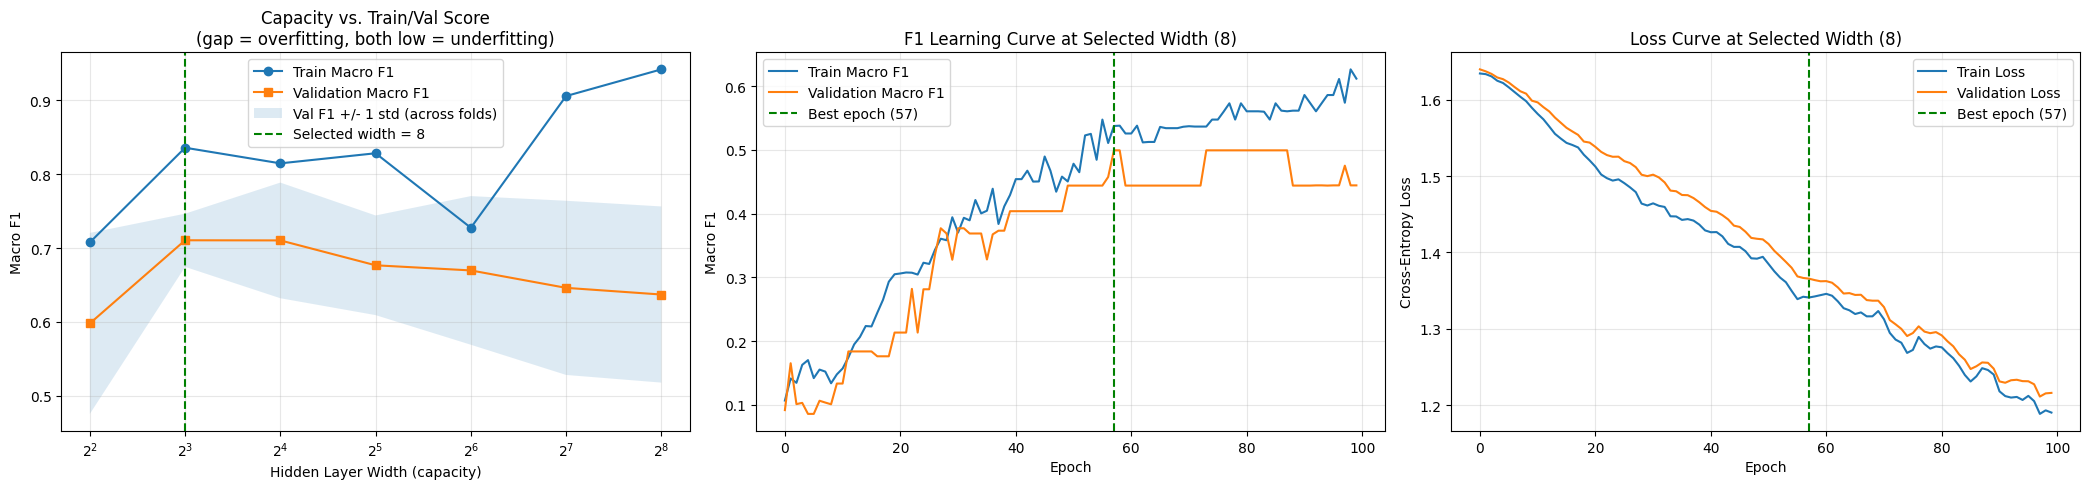

In [181]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

# --- Plot 1: capacity (model complexity) curve, the classic
#     bias/variance diagnostic: train vs. validation score vs. width ---
ax = axes[0]
ax.plot(cv_df["hidden_dim"], cv_df["mean_train_f1"], marker="o", label="Train Macro F1")
ax.plot(cv_df["hidden_dim"], cv_df["mean_val_f1"], marker="s", label="Validation Macro F1")
ax.fill_between(cv_df["hidden_dim"],
                 cv_df["mean_val_f1"] - cv_df["std_val_f1"],
                 cv_df["mean_val_f1"] + cv_df["std_val_f1"],
                 alpha=0.15, label="Val F1 +/- 1 std (across folds)")
ax.axvline(best_hidden_dim, color="green", linestyle="--", label=f"Selected width = {best_hidden_dim}")
ax.set_xscale("log", base=2)
ax.set_xlabel("Hidden Layer Width (capacity)")
ax.set_ylabel("Macro F1")
ax.set_title("Capacity vs. Train/Val Score\n(gap = overfitting, both low = underfitting)")
ax.legend()
ax.grid(alpha=0.3)

# --- Plot 2: learning curves for the SELECTED capacity, to check
#     the train/val trajectory over epochs (not just the final value) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_np)
X_validation_scaled = scaler.transform(X_validation_np)

_, _, best_history = train_dnn(
    X_train_scaled, y_train_enc,
    X_validation_scaled, y_validation_enc,
    n_classes=N_CLASSES, hidden_dim=best_hidden_dim, epochs=100,
)
best_epoch_marker = best_history["best_epoch"]

# --- Plot 2: Macro F1 learning curve ---
ax = axes[1]
ax.plot(best_history["train_f1"], label="Train Macro F1")
ax.plot(best_history["val_f1"], label="Validation Macro F1")
ax.axvline(best_epoch_marker, color="green", linestyle="--",
           label=f"Best epoch ({best_epoch_marker})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Macro F1")
ax.set_title(f"F1 Learning Curve at Selected Width ({best_hidden_dim})")
ax.legend()
ax.grid(alpha=0.3)

# --- Plot 3: Loss function (cross-entropy) learning curve.
#     A rising val_loss while train_loss keeps falling is the
#     clearest sign of overfitting (cleater than F1 alone, since
#     loss is continuous while F1 is a thresholded metric). ---
ax = axes[2]
ax.plot(best_history["train_loss"], label="Train Loss")
ax.plot(best_history["val_loss"], label="Validation Loss")
ax.axvline(best_epoch_marker, color="green", linestyle="--",
           label=f"Best epoch ({best_epoch_marker})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-Entropy Loss")
ax.set_title(f"Loss Curve at Selected Width ({best_hidden_dim})")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [185]:
X_train_full = np.vstack([X_train_np, X_validation_np])
y_train_full = np.concatenate([y_train_enc, y_validation_enc])

# Recalculate scaling using ALL training data
final_scaler = StandardScaler()
X_train_full_scaled = final_scaler.fit_transform(X_train_full)
X_test_scaled = final_scaler.transform(X_test_np)

print("Final training shape:", X_train_full_scaled.shape)
print("Final test shape:", X_test_scaled.shape)
print("Using optimal capacity found by cross-validation: hidden_dim =", best_hidden_dim)

final_model, _, final_history = train_dnn(
    X_train_full_scaled, y_train_full,
    X_test_scaled, y_test_enc,   # used only to track the best epoch by macro F1, same role val set played above
    n_classes=N_CLASSES, hidden_dim=best_hidden_dim, epochs=1000,
)

final_model.eval()
with torch.no_grad():
    test_predictions = final_model(torch.from_numpy(X_test_scaled).float().to(device)).argmax(1).cpu().numpy()


Final training shape: (100, 13)
Final test shape: (50, 13)
Using optimal capacity found by cross-validation: hidden_dim = 8


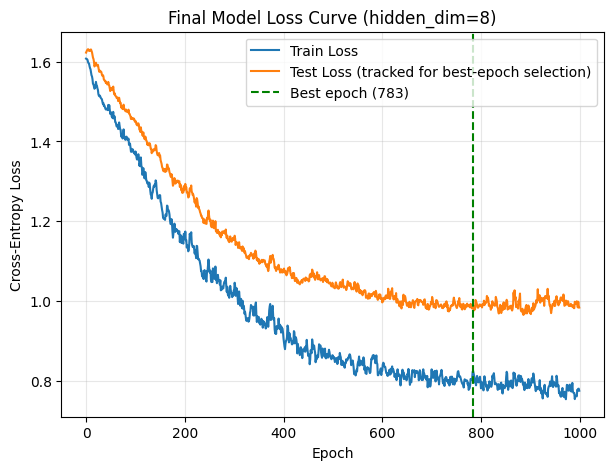

In [187]:
# Loss curve of the final model (trained on train+val, tracked against test)
plt.figure(figsize=(7, 5))
plt.plot(final_history["train_loss"], label="Train Loss")
plt.plot(final_history["val_loss"], label="Test Loss (tracked for best-epoch selection)")
final_best_epoch = final_history["best_epoch"]
plt.axvline(final_best_epoch, color="green", linestyle="--", label=f"Best epoch ({final_best_epoch})")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title(f"Final Model Loss Curve (hidden_dim={best_hidden_dim})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [189]:
print("Test Accuracy:", accuracy_score(y_test_enc, test_predictions))
print("Test Macro F1:", f1_score(y_test_enc, test_predictions, average="macro"))
print("\nClassification Report:")
print(classification_report(y_test_enc, test_predictions, target_names=label_encoder.classes_))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_enc, test_predictions))


Test Accuracy: 0.64
Test Macro F1: 0.6316012252854357

Classification Report:
              precision    recall  f1-score   support

         DCM       0.73      0.80      0.76        10
         HCM       0.60      0.30      0.40        10
        MINF       0.75      0.60      0.67        10
         NOR       0.47      0.80      0.59        10
          RV       0.78      0.70      0.74        10

    accuracy                           0.64        50
   macro avg       0.67      0.64      0.63        50
weighted avg       0.67      0.64      0.63        50


Confusion Matrix:
[[8 1 1 0 0]
 [0 3 1 6 0]
 [3 1 6 0 0]
 [0 0 0 8 2]
 [0 0 0 3 7]]
